# CCE Moorings and MITgcm - Regional Temporal Scales Analysis   

**Purpose**: Code for comparing the CCE mooring scale analysis with the profile time series from the MITgcm model.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator
import re

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from plotScaleAnalysis import add_corner_label, plot_regional_decor

Set data analysis parameters

In [10]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted

# Set space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set plotting parameters 
depth_lim = [0,200]
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Decorrelation Scale (days)'

# Set font ()and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load CCE intermediate data and mitgcm time scale analysis data

In [4]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm   = "/data/mitgcm/SWOT_MARA_RUN4_LY/spatial"
filename_rho  = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_density_depth_*m_unc.npz")
filename_u    = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_uvel_depth_*m_unc.npz")
filename_v    = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_vvel_depth_*m_unc.npz")

# Sort files by depth 
filename_rho_sort = sorted(filename_rho,key=lambda f: float(re.search(r"_depth_([0-9]*\.?[0-9]+)m", f).group(1)))
filename_u_sort   = sorted(filename_u,key=lambda f: float(re.search(r"_depth_([0-9]*\.?[0-9]+)m", f).group(1)))
filename_v_sort   = sorted(filename_v,key=lambda f: float(re.search(r"_depth_([0-9]*\.?[0-9]+)m", f).group(1)))

#--- Potential Density ---# 

# Set array 
Lt_rho      = []
Lt_rho_stdm = []

# Obtain depth levels from filenames
depth_rho_m = [f.split("_depth_")[1].split("m")[0] for f in filename_rho_sort]
depth_rho_m = [float(d) for d in depth_rho_m]   # convert to int

# Set counter 
cn = 0

# Loop through files
for f in filename_rho_sort:

    # Load data 
    ds_rho   = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and its uncertainty
    Lt_rho.append(ds_rho["Lt_days"])            # Units: days
    Lt_rho_stdm.append(ds_rho['Lt_stdm_days'])

    # Extract coordinates
    if cn == 0:
        lon_rho_m = ds_rho["lon"]
        lat_rho_m = ds_rho["lat"]

    # Reset counter 
    cn += 1

#--- Along-shore Velocity ---# 

# Set array 
Lt_u      = []
Lt_u_stdm = []

# Obtain depth levels from filenames
depth_u_m = [f.split("_depth_")[1].split("m")[0] for f in filename_u_sort]
depth_u_m = [int(d) for d in depth_u_m]   # convert to int

# Set counter 
cn = 0

# Loop through files
for f in filename_u_sort:

    # Load data 
    ds_u = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and its uncertainty
    Lt_u.append(ds_u["Lt_days"])                # Units: days
    Lt_u_stdm.append(ds_u['Lt_stdm_days'])

    # Extract coordinates
    if cn == 0:
        lon_u_m = ds_u["lon"]
        lat_u_m = ds_u["lat"]

    # Reset counter 
    cn += 1

#--- Cross-shore Velocity ---# 

# Set array 
Lt_v      = []
Lt_v_stdm = []

# Obtain depth levels from filenames
depth_v_m = [f.split("_depth_")[1].split("m")[0] for f in filename_v_sort]
depth_v_m = [int(d) for d in depth_v_m]   # convert to int

# Set counter 
cn = 0

# Loop through files
for f in filename_v_sort:

    # Load data 
    ds_v = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and its uncertainty
    Lt_v.append(ds_v["Lt_days"])                # Units: days
    Lt_v_stdm.append(ds_v['Lt_stdm_days'])

    # Extract coordinates
    if cn == 0:
        lon_v_m = ds_v["lon"]
        lat_v_m = ds_v["lat"]

    # Reset counter 
    cn += 1

# Convert lists to arrays
Lt_rho = np.array(Lt_rho)
Lt_u   = np.array(Lt_u)
Lt_v   = np.array(Lt_v)
Lt_rho_stdm = np.array(Lt_rho_stdm)
Lt_u_stdm   = np.array(Lt_u_stdm)
Lt_v_stdm   = np.array(Lt_v_stdm)

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_data_gridded.npz")
filename_CCE1_ADCP = glob.glob(PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_*_scale_data.npz")
filename_CCE2_ADCP = glob.glob(PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_*_scale_data.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

ds_CCE1_ADCP   = np.load(filename_CCE1_ADCP[0], allow_pickle=True)
ds_CCE2_ADCP   = np.load(filename_CCE2_ADCP[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
lon1             = ds_CCE1_CTD["lon"] %360
lat1             = ds_CCE1_CTD["lat"]
depth1           = ds_CCE1_CTD["depth"]

Lt1_rho          = ds_CCE1_CTD["Lt_seg_rho"]      # Units: days

#--- CCE2 ---# 
lon2             = ds_CCE2_CTD["lon"] %360
lat2             = ds_CCE2_CTD["lat"]
depth2           = ds_CCE2_CTD["depth"]

Lt2_rho          = ds_CCE2_CTD["Lt_seg_rho"]      # Units: days

#--- CCE3 ---# 
lon3 = -120.53825701527784 % 360
lat3 = 34.44825228022894

Read in CalCOFI stations

In [13]:
# Load CalCOFI csv file 
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Read in bathymetry data

In [5]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [6]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_rho,axis=(1,2)) 
# Lt_u_spatial_mean   = np.mean(Lt_u,axis=(1,2)) 
# Lt_v_spatial_mean   = np.mean(Lt_v,axis=(1,2)) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_rho_stdm / (Lt_rho - Lt_rho_spatial_mean[:,None,None])
# Lt_u_rel_unc   = Lt_u_stdm / Lt_u
# Lt_v_rel_unc   = Lt_v_stdm / Lt_v

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))
# Lt_u_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_u_rel_unc, (ns)))
# Lt_v_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_v_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)
# u_mask   = np.where(Lt_u_mask, 1, np.nan)
# v_mask   = np.where(Lt_v_mask, 1, np.nan)

Plot the decorrelation scales for three depths

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: '

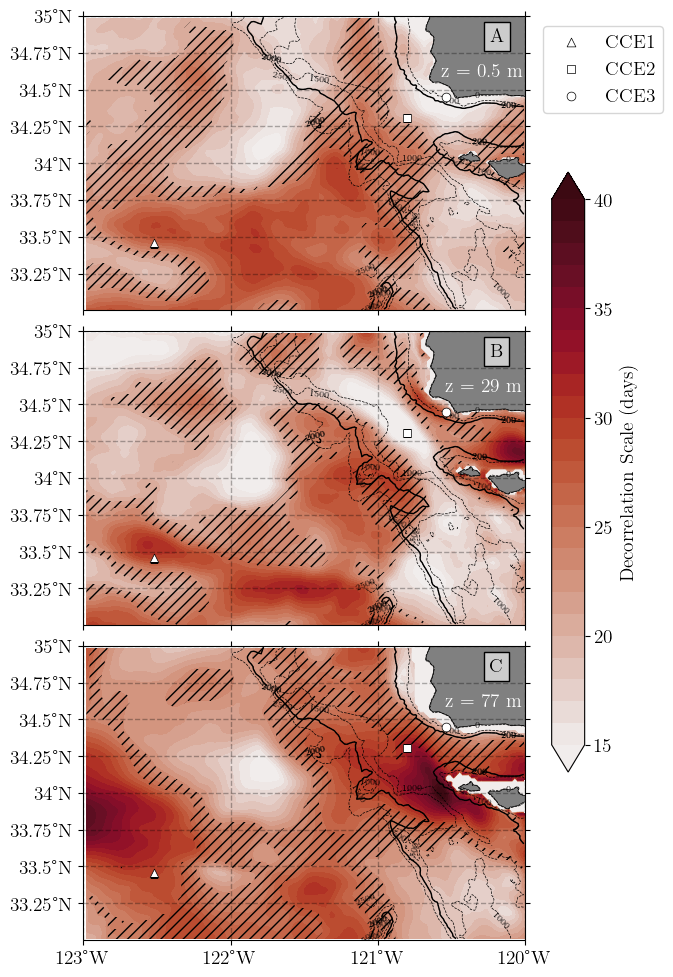

<Figure size 640x480 with 0 Axes>

In [12]:
# Set plotting parameters
vmin = 15
vmax = 40
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(3,1, figsize=(22, 12), subplot_kw={"projection": projection})
ax_flat = axes.flatten()

##############################
#--- Subplot 1 ---# 
##############################
ax = ax_flat[0]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[0]))

# Plot regional decorrelation scale
cf = plot_regional_decor(ax,Lt_rho[0,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[0,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.81, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[0]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # (x, y) in axes coordinates of ax1
    frameon=True
)

##############################
#--- Subplot 2 ---# 
##############################
ax = ax_flat[1]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[1]))

# Plot regional decorrelation scale
_ = plot_regional_decor(ax,Lt_rho[2,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[2,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[2]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

##############################
#--- Subplot 3 ---# 
##############################
ax = ax_flat[2]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[2]))

# Plot regional decorrelation scale
_ = plot_regional_decor(ax,Lt_rho[3,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[3,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[3]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.625, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Label each subplot
ax1, ax2, ax3 = axes.flatten()
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Show the plot
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()

# Show figure
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig14.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Plot decorrelation sclaes for 4 depths

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: '

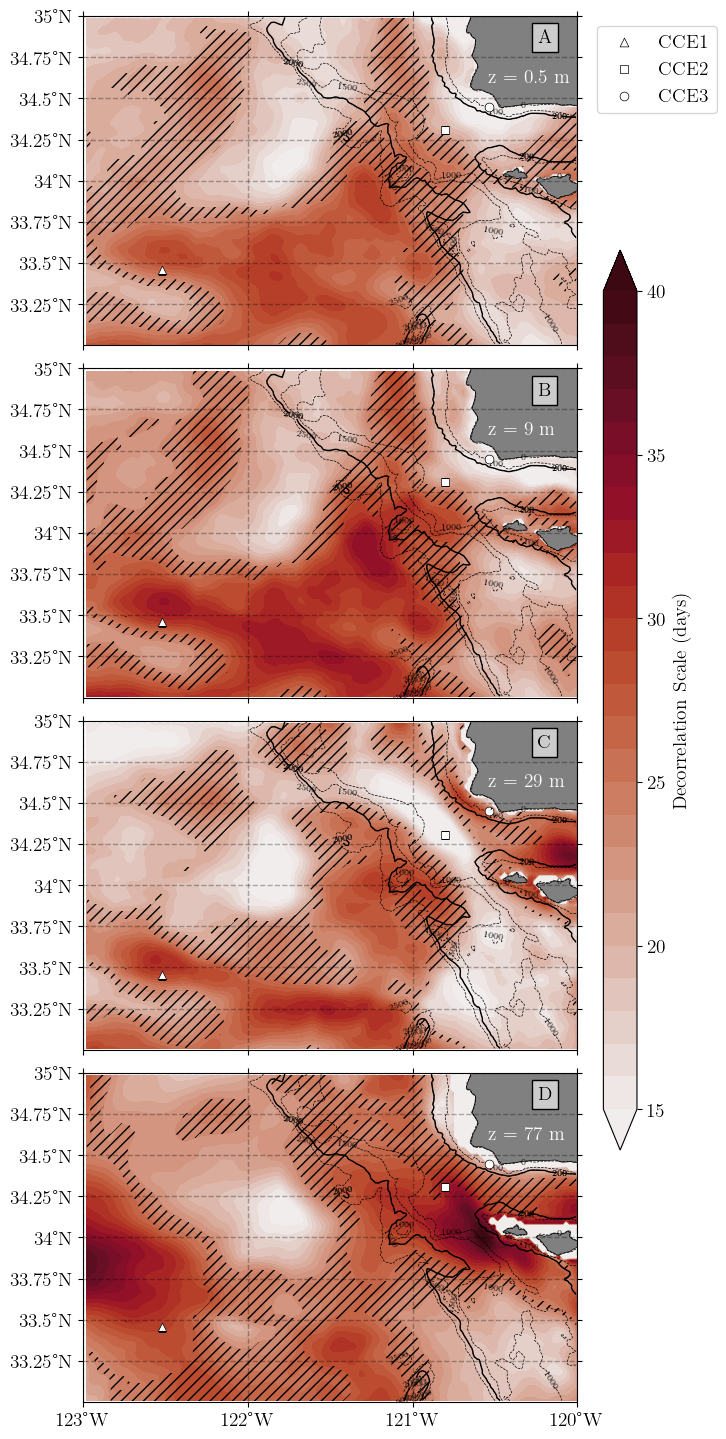

<Figure size 640x480 with 0 Axes>

In [14]:
# Set plotting parameters
vmin = 15
vmax = 40
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(4,1, figsize=(28, 18), subplot_kw={"projection": projection})
ax_flat = axes.flatten()

##############################
#--- Subplot 1 ---# 
##############################
ax = ax_flat[0]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[0]))

# Plot regional decorrelation scale
cf = plot_regional_decor(ax,Lt_rho[0,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[0,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[0]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # (x, y) in axes coordinates of ax1
    frameon=True
)

##############################
#--- Subplot 2 ---# 
##############################
ax = ax_flat[1]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[1]))

# Plot regional decorrelation scale
_ = plot_regional_decor(ax,Lt_rho[1,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[1,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[1]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

##############################
#--- Subplot 3 ---# 
##############################
ax = ax_flat[2]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[2]))

# Plot regional decorrelation scale
_ = plot_regional_decor(ax,Lt_rho[2,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[2,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[2]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

##############################
#--- Subplot 4 ---# 
##############################
ax = ax_flat[3]

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[3]))

# Plot regional decorrelation scale
_ = plot_regional_decor(ax,Lt_rho[3,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[3,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Label depth level 
ax.text(0.82, 0.84,              # (x,y) in axes coords (0–1)
        f"z = {depth_rho_m[3]:g} m",              # depth text
        transform=ax.transAxes,fontsize=fontsize, ha="left", va="top",
        color='w',fontweight='bold')

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.61, 0.25, 0.012, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Label each subplot
ax1, ax2, ax3, ax4 = axes.flatten()
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)

# Show the plot
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()

# Show figure
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig14_alt.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

In [8]:
def add_scalebar(ax, length_km=50, location=(0.15, 0.07),
                 linewidth=2, text_kwargs=None):
    """
    Add a horizontal scale bar to a Cartopy GeoAxes.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        The axes to draw the scale bar on.
    length_km : float
        Length of the scale bar in kilometers.
    location : tuple of float
        Location of the center of the scale bar in *axes* coordinates
        (x, y), both between 0 and 1.
    linewidth : float
        Line width of the scale bar.
    text_kwargs : dict, optional
        Extra kwargs passed to ax.text (fontsize, weight, etc.).
    """

    # Import libraries
    import numpy as np
    import cartopy.crs as ccrs
    import matplotlib.pyplot as plt

    if text_kwargs is None:
        text_kwargs = dict(fontsize=10)

    # Get current map extent in data (PlateCarree) coordinates
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(crs=ccrs.PlateCarree())

    # Choose the latitude where the bar will be drawn
    lat = lat_min + location[1] * (lat_max - lat_min)

    # Convert desired length (km) to degrees of longitude at that latitude
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat))
    dlon = (length_km / km_per_deg_lon)

    # Choose center longitude based on axes location
    lon_center = lon_min + location[0] * (lon_max - lon_min)
    lon_left   = lon_center - dlon / 2
    lon_right  = lon_center + dlon / 2

    # Small vertical tick height in degrees
    dtick = 0.01 * (lat_max - lat_min)

    # Horizontal bar
    ax.plot([lon_left, lon_right], [lat, lat],
            transform=ccrs.PlateCarree(),
            color='k', linewidth=linewidth, solid_capstyle='butt')

    # Vertical ticks at ends (to make |-----|)
    ax.plot([lon_left, lon_left],
            [lat - dtick, lat + dtick],
            transform=ccrs.PlateCarree(),
            color='k', linewidth=linewidth)
    ax.plot([lon_right, lon_right],
            [lat - dtick, lat + dtick],
            transform=ccrs.PlateCarree(),
            color='k', linewidth=linewidth)

    # Label above the bar
    ax.text(lon_center, lat + 1.8 * dtick,
            f"{int(length_km)} km",
            ha='center', va='bottom',
            transform=ccrs.PlateCarree(),
            **text_kwargs)


/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_51795/3368703105.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


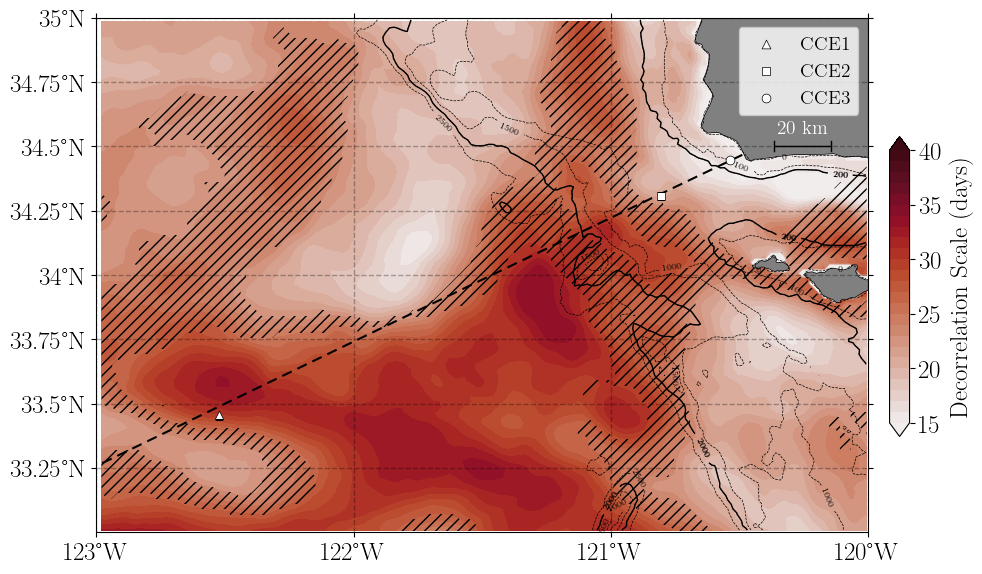

In [18]:
# Set plotting parameters
vmin = 15
vmax = 40
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
option_cce = 1
fontsize = 18

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, ax = plt.subplots(1,1, figsize=(10, 6), subplot_kw={"projection": projection})

##############################
#--- Subplot 1 ---# 
##############################

# Find depth index for closests observed decorrelation scale
idx = np.argmin(abs(depth1 - depth_rho_m[1]))

# Plot regional decorrelation scale
cf = plot_regional_decor(ax,Lt_rho[1,:,:],lon_rho_m,lat_rho_m,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,lon3,lat3,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    lon_rho_m,
    lat_rho_m,
    rho_mask[0,:,:],
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
    transform=ccrs.PlateCarree()
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
    #label='CalCOFI Line 80.0'
)

# Set tick parameters
ax.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")
ax.legend(
    loc='upper right',
    frameon=True, 
    fontsize=14
)

# Set color bar
cax = fig.add_axes([0.93, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Add a 50-km scale bar near the lower-left
add_scalebar(ax, length_km=20, location=(0.915, 0.75),
             linewidth=1, text_kwargs=dict(fontsize=14, color='white', weight='bold'))

# Show figure
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig06.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)